# Traveller Sector Generator

Generates a whole sector and renders it in the style of the Classic Traveller
maps, using the `worldmaker` package.

This notebook is a thin front-end over the tested package; the rules are not
duplicated here.


In [1]:
import random

import worldmaker as wm

random.seed(1105)

# A full sector is 32x40 hexes: sixteen 8x10 subsectors, generated in one pass
# so polities, routes and names are coherent across the whole map.
sector = wm.generate_full_sector("Foreven Reach")
print(f"{len(sector.systems)} systems in {sector.width}x{sector.height} hexes")
print(f"{len(sector.polities)} polities, "
      f"{sum(1 for r in sector.routes if r[2] == 'xboat')} Xboat links")

647 systems in 32x40 hexes
5 polities, 166 Xboat links


## Polities

In [2]:
for p in sector.polities:
    print(f"{p.allegiance_code}  {p.name:34s} capital {p.capital_hex}  "
          f"{len(p.controlled_systems):3d} worlds  DI {p.defense_index:2d}  "
          f"{p.polity_type}")

unaligned = sum(1 for s in sector.systems.values() if s.allegiance == "Na")
print(f"\n{unaligned} independent systems")

Ja  Jarrow Imperium                    capital 2013   80 worlds  DI 12  Interstellar Empire
Av  Avalar Federation                  capital 0807   47 worlds  DI 11  Interstellar Empire
De  Delphi Federation                  capital 2505   16 worlds  DI 11  Interstellar State
Us  Ushant Protectorate                capital 0118   46 worlds  DI 10  Interstellar Empire
La  Lanth Imperium                     capital 1210   14 worlds  DI  5  Major Race Polity

444 independent systems


## Subsectors

In [3]:
for letter, name in sorted(sector.subsector_names.items()):
    idx = ord(letter) - 65
    col0, row0 = (idx % 4) * 8, (idx // 4) * 10
    count = sum(
        1 for h in sector.systems
        if col0 < int(h[:2]) <= col0 + 8 and row0 < int(h[2:]) <= row0 + 10)
    print(f"{letter}  {name:16s} {count:3d} systems")

A  Zororia           47 systems
B  Denoren           45 systems
C  Falunan           39 systems
D  Norelax           38 systems
E  Henoel            36 systems
F  Norenim           39 systems
G  Ruia              40 systems
H  Xenenia           49 systems
I  Ivana             35 systems
J  Soreris           43 systems
K  Laneran           32 systems
L  Urunel            41 systems
M  Renenyr           38 systems
N  Vanenus           38 systems
O  Ardolim           46 systems
P  Calelis           41 systems


## Sector map\n\nThe full foldout, in the classic black-ink style.

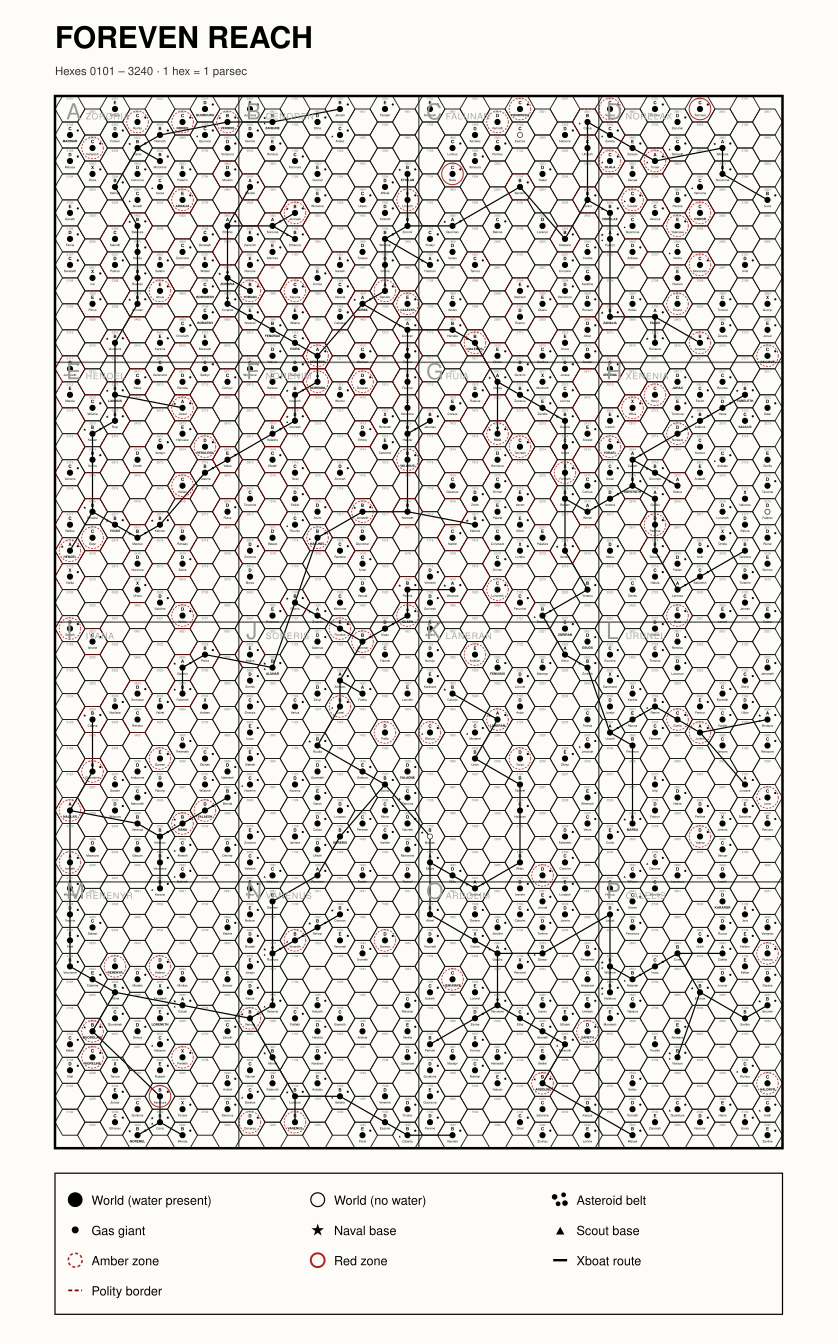

In [4]:
from IPython.display import SVG, display

display(SVG(wm.generate_sector_svg(sector)))

## Subsector map\n\nA single subsector at Supplement-page scale.

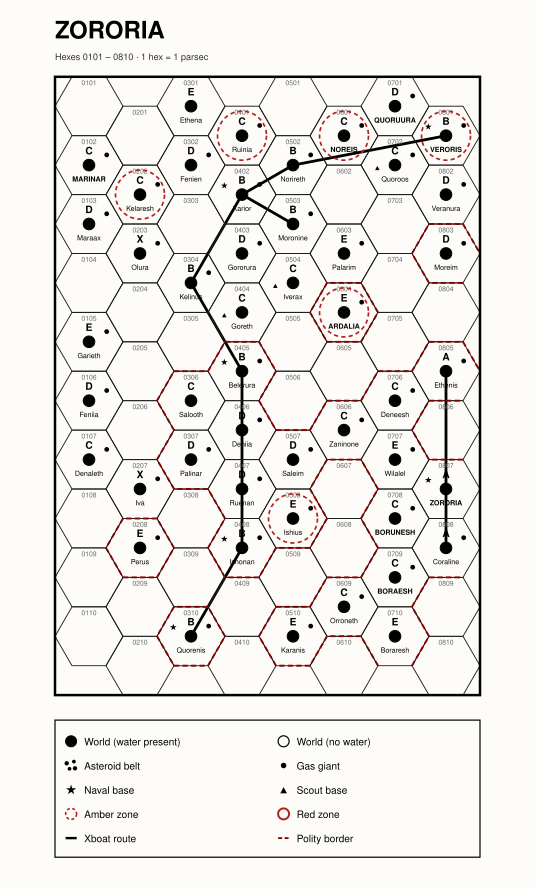

In [5]:
display(SVG(wm.generate_subsector_svg(sector, sector.subsector_names.get('A', 'Subsector A'))))

### Any other subsector

Pass the origin hex of the subsector window: subsector F starts at 0911.

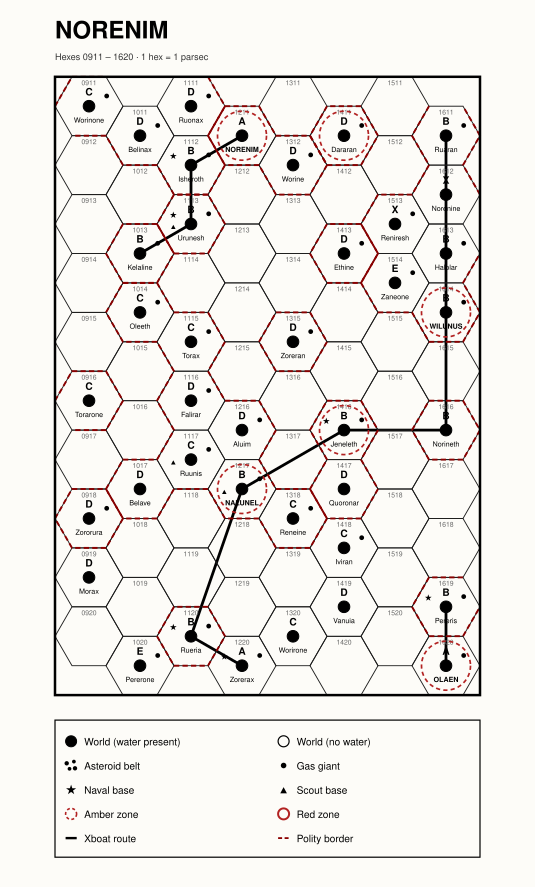

In [6]:
display(SVG(wm.generate_subsector_svg(
    sector, sector.subsector_names.get('F', 'Subsector F'),
    origin_col=9, origin_row=11)))

## Building a sector from a universe

The *Sector Construction Guide* opens by asking a handful of questions
before any dice are rolled (pp.3-8): what the theme is, how densely the
stars are packed, how advanced the setting is, whether it is growing or
falling, and whether any anomaly bends the rules over part of the map.
`create_universe()` takes those answers and drives generation from them.

In [7]:
universe = wm.create_universe("Foreven Reach", preset="frontier")

# A "Bermuda Triangle" where colonies fail, and a rift that thins the stars
universe.add_anomaly("barren", "The Quiet Zone", centre="1124", radius=2)
universe.add_anomaly("rift", "The Gap", centre="0505", radius=2)

wm.build_default_timeline(universe)
print(universe.describe())

# Foreven Reach

**Theme**: Expansion and conflict along a contested frontier
**Star density**: scattered (system on 1D 5+)
**Maximum Tech Level**: 11 (developing)
**Trajectory**: expansion (population DM +1)
**Native sophonts**: standard
**Interstellar polities**: 2
**Current year**: 1105

## Background
Newly opened space. Settlement waves are still moving outward and few worlds have been charted twice.

## Anomalies
- **The Quiet Zone** (19 hexes): Failed colonies and lost ships; the worlds stand empty
- **The Gap** (19 hexes): An interstellar rift: few or no systems

## Timeline
- -298895: Ancient civilisation active in the region; sophonts transplanted between worlds
- 305: First interstellar arrivals in the region
- 705: Widespread settlement begins
- 905: The current wave of expansion begins
- 1005: The Quiet Zone: the last colony attempt fails
- 1065: Frontier surveys reach the far side of the region


In [8]:
random.seed(1105)
themed = wm.generate_universe_sector(universe, "Foreven Reach")
print(f"{len(themed.systems)} systems, {len(themed.polities)} polities")

# The rift is empty, and the Quiet Zone's worlds stand abandoned
rift = universe.anomalies[1].hexes
print(f"systems inside the rift: {sum(1 for h in rift if h in themed.systems)}")

for hex_coord in universe.anomalies[0].hexes:
    system = themed.systems.get(hex_coord)
    if system and system.mainworld:
        print(f"  {hex_coord}  {system.mainworld.uwp}  "
              f"{' '.join(system.mainworld.trade_codes)}")

405 systems, 2 polities
systems inside the rift: 0
  0925  XB96000-0  Ba
  1122  XCDA000-0  Fl Ba
  1126  X787000-0  Ga Ba


## Sector data file

Traveller5 Second Survey data, in the column-delimited format
travellermap.com defines. The separator line fixes each field's width, so
every value sits in its own column: Hex, Name, UWP, Remarks, then the
importance, economic and cultural extensions, nobility, bases, travel
zone, PBG, world count, allegiance and stellar data.

In [9]:
sec_data = wm.export_sector_sec_file(sector)
print("\n".join(sec_data.splitlines()[:25]))
print("...")

# Foreven Reach
# Traveller5 Second Survey, column delimited
# Subsector A: Zororia
# Subsector B: Denoren
# Subsector C: Falunan
# Subsector D: Norelax
# Subsector E: Henoel
# Subsector F: Norenim
# Subsector G: Ruia
# Subsector H: Xenenia
# Subsector I: Ivana
# Subsector J: Soreris
# Subsector K: Laneran
# Subsector L: Urunel
# Subsector M: Renenyr
# Subsector N: Vanenus
# Subsector O: Ardolim
# Subsector P: Calelis
#
Hex  Name        UWP       Remarks            {Ix}   (Ex)    [Cx]   N     B   Z PBG W  A  Stellar
---- ----------- --------- ------------------ ------ ------- ------ ----- --- - --- -- -- ------------------------
0102 Marinar     C888A86-7 Hi                 { 0 }  (A99+2) [6C88] B           501 25 Na K8 V K3 V
0103 Maraax      DED647A-A Fl Ni              { -1 } (F35-5) [656A] B     M     403 45 Na K7 III
0105 Garieth     EA97777-4 Ag Lt              { -2 } (C63+1) [177B] B           803 46 Na A6 V
0106 Feniia      D875343-4 Lo Lt              { -3 } (820+1) [744A] B  

In [10]:
# Write the maps and data to disk
with open("sector_map.svg", "w") as f:
    f.write(wm.generate_sector_svg(sector))
with open("sector.sec", "w") as f:
    f.write(sec_data)
print("written: sector_map.svg, sector.sec")

written: sector_map.svg, sector.sec
